In [20]:
import pandas as pd

pd.set_option("copy_on_write", True)

ncaa_nba = pd.read_csv("data/ncaa_nba_data.csv", na_values=["NA"])
ncaa_nba.sample(5)

,Player,College,draft_year,Pk,athlete_id,team_location,num_years_college,college_1,college_2,college_3,college_4,nba_season_1,nba_season_2,nba_season_3,nba_season_4,nba_season_5
82,Byron Mullens,Ohio State,2009,24,41747,Ohio State,1,3.642,NaN,NaN,NaN,-4.00,-3.82,-3.03,-3.47,-2.57
21,Alex Oriakhi,Missouri,2013,57,45946,Missouri,4,7.521,9.650,11.093,13.329,-10.00,NaN,NaN,NaN,NaN
120,Cleanthony Early,Wichita State,2014,34,62186,Wichita State,2,8.337,12.264,NaN,NaN,-2.21,-3.01,NaN,NaN,NaN
791,Will Richard,Florida,2025,56,4897262,Florida,4,5.584,5.713,9.332,13.329,-0.63,NaN,NaN,NaN,NaN
134,Cory Joseph,Texas,2011,29,51445,Texas,1,5.105,NaN,NaN,NaN,-1.85,-1.42,0.09,0.21,-0.78


## Matching: one extra year of college vs. one-and-done

**Question:** Among players who *could* plausibly leave after freshman year, what is the association between **staying two years** (`num_years_college == 2`) vs. **one-and-done** (`num_years_college == 1`) on **later NBA season metrics** (`nba_season_1`–`nba_season_5`)?

**Design:** Binary treatment = 2 years vs. 1 year.

Pre-treatment covariate for matching = **freshman performance** (`college_1`) only (we do not match on `college_2`, `Pk`, or `draft_year`, which are downstream of the stay/leave decision). 

**Estimand:** ATT — average effect on **treated** (two-year players) of having a matched one-and-done counterfactual with similar `college_1`. 

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logit as logit_fn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import PolynomialFeatures

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

In [22]:
# Restrict to 1 vs 2 years; require freshman metric for overlap-based matching
analysis = ncaa_nba.loc[ncaa_nba["num_years_college"].isin([1, 2])].copy()
analysis["treat"] = (analysis["num_years_college"] == 2).astype(int)

before_n = len(analysis)
analysis = analysis.dropna(subset=["college_1"])
print(
    f"Rows with num_years_college in {{1,2}}: {before_n}; after dropna(college_1): {len(analysis)}"
)
print(
    analysis["treat"].value_counts().rename({0: "one-and-done (0)", 1: "two years (1)"})
)

Rows with num_years_college in {1,2}: 393; after dropna(college_1): 393
treat
one-and-done (0)    214
two years (1)       179
Name: count, dtype: int64


**Central Trimming**:  trims the sample to the central 90% of freshman stats to keep both treated and control units in the data for a given level of the matching variables.

In [23]:
# Restrict to overlapping freshman-performance region (both groups present)
q_lo, q_hi = 0.05, 0.95
lo, hi = analysis["college_1"].quantile([q_lo, q_hi])
overlap_mask = analysis["college_1"].between(lo, hi)
print(
    f"Overlap band on college_1: [{lo:.3f}, {hi:.3f}] (quantiles {q_lo:.0%}-{q_hi:.0%})"
)
print(
    "Counts in band — treat=0:",
    int((overlap_mask & (analysis["treat"] == 0)).sum()),
    "treat=1:",
    int((overlap_mask & (analysis["treat"] == 1)).sum()),
)

USE_OVERLAP_RESTRICTION = True
df = analysis.loc[overlap_mask].copy() if USE_OVERLAP_RESTRICTION else analysis
print(f"\nAnalysis sample size: {len(df)}")

Overlap band on college_1: [3.202, 17.246] (quantiles 5%-95%)
Counts in band — treat=0: 194 treat=1: 159

Analysis sample size: 353


**Covariates X**: It takes `college_1` and expands it with `PolynomialFeatures(degree=2)` (linear + squared term, no intercept column in the design matrix because include_bias=False). So the propensity model allows a curved relationship between freshman performance and the probability of being a two-year player.

**Treatment** `T: treat == 1` means two years in college; 0 means one-and-done.

**Propensity score:** `LogisticRegression` estimates $\hat e(X) = P(T=1 \mid X)$ using those polynomial features. `predict_proba[:, 1]` is that fitted probability for each row. It is stored as **`propensity_score`** on `df`.

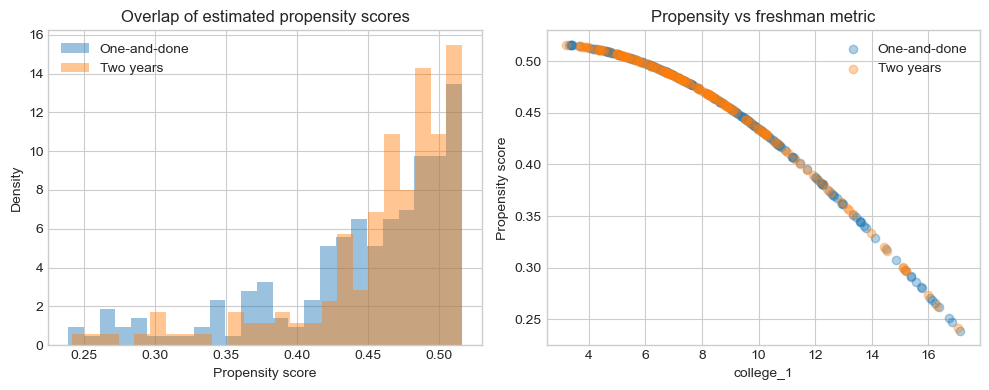

In [24]:
# Propensity score e(X) = P(T=1 | X); X = linear + quadratic in college_1
X_raw = df[["college_1"]].to_numpy()
poly = PolynomialFeatures(degree=2, include_bias=False)
X = poly.fit_transform(X_raw)
T = df["treat"].to_numpy()

ps_clf = LogisticRegression(max_iter=5000, solver="lbfgs")
ps_clf.fit(X, T)
ps = ps_clf.predict_proba(X)[:, 1]
df = df.assign(propensity_score=ps)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for t, label, color in [(0, "One-and-done", "C0"), (1, "Two years", "C1")]:
    ax[0].hist(
        df.loc[df["treat"] == t, "propensity_score"],
        bins=25,
        alpha=0.45,
        label=label,
        color=color,
        density=True,
    )
ax[0].set_xlabel("Propensity score")
ax[0].set_ylabel("Density")
ax[0].legend()
ax[0].set_title("Overlap of estimated propensity scores")

ax[1].scatter(
    df.loc[df["treat"] == 0, "college_1"],
    df.loc[df["treat"] == 0, "propensity_score"],
    alpha=0.35,
    label="One-and-done",
)
ax[1].scatter(
    df.loc[df["treat"] == 1, "college_1"],
    df.loc[df["treat"] == 1, "propensity_score"],
    alpha=0.35,
    label="Two years",
)
ax[1].set_xlabel("college_1")
ax[1].set_ylabel("Propensity score")
ax[1].legend()
ax[1].set_title("Propensity vs freshman metric")
plt.tight_layout()
plt.show()

- **Overlap of estimated propensity scores** (left):

    - The two groups share propensity mass mainly in the upper half of the range (roughly about 0.4–0.55), so there is meaningful common support for comparing one-and-dones and two-year players. 

    - The two-year group piles up at the highest propensities, while one-and-dones are more spread out, with a long tail toward low propensities where almost no two-year players appear. 

    - So **matching is most credible in the mid-to-high propensity region**; the very low propensity end is dominated by one-and-dones, which makes “peer” comparisons to two-year players harder or impossible there.

- **Propensity vs. freshman metric** (right):
    - The fitted model implies a nonlinear link between college_1 and the chance of a second year: propensity is highest for moderate freshman performance (around a college_1 of about 6–8) and falls toward both lower and, especially, higher freshman numbers. 
    
    - One-and-dones (blue) are spread across the whole `college_1` range, but they are concentrated at the high end, where propensity is very low—a region with little orange (two-year) representation. 
    
    - In contrast, two-year players cluster more where propensity is highest (roughly the “middle” of the freshman-metric scale). That pattern is somewhat mediated by central overlap trimming since the extreme freshman tails are not symmetrically populated by both treatment types.

In [25]:
def standardized_mean_diff(x_treat, x_control):
    """
    computes the standardized mean difference (SMD) between treated and
    control values of a variable that used later to assess covariate balance
    """
    m1, m0 = np.nanmean(x_treat), np.nanmean(x_control)
    s1, s0 = np.nanstd(x_treat, ddof=1), np.nanstd(x_control, ddof=1)
    sp = np.sqrt((s1**2 + s0**2) / 2)
    return (m1 - m0) / sp if sp > 0 else np.nan


def att_nearest_neighbor_on_logit_ps(df_in, caliper_mult=0.25, replace=False):
    """
    ATT matching: each treated matched to nearest control on logit(PS).
    Rubin caliper on logit(PS).
    """
    d = df_in.reset_index(drop=True)
    ps = d["propensity_score"].to_numpy()
    logit_ps = logit_fn(np.clip(ps, 1e-6, 1 - 1e-6))
    treat = d["treat"].to_numpy().astype(bool)
    treated_idx = np.flatnonzero(treat)
    control_idx = np.flatnonzero(~treat)
    if len(treated_idx) == 0 or len(control_idx) == 0:
        return np.array([]), np.array([]), float("nan")

    caliper = caliper_mult * np.std(logit_ps, ddof=1)
    nn = NearestNeighbors(n_neighbors=1, algorithm="auto").fit(
        logit_ps[control_idx].reshape(-1, 1)
    )
    dist, nn_local = nn.kneighbors(logit_ps[treated_idx].reshape(-1, 1))
    dist = dist.ravel()
    nn_local = nn_local.ravel()

    pairs_t, pairs_c = [], []
    used_controls = set()
    order = np.argsort(dist)  # greedily match closest pairs first when no replacement
    for k in order:
        ti = treated_idx[k]
        ci = control_idx[nn_local[k]]
        if dist[k] > caliper:
            continue
        if not replace and ci in used_controls:
            continue
        pairs_t.append(ti)
        pairs_c.append(ci)
        if not replace:
            used_controls.add(ci)

    return np.array(pairs_t), np.array(pairs_c), caliper


pairs_t, pairs_c, caliper_used = att_nearest_neighbor_on_logit_ps(df)
print(f"Caliper (0.25 * SD logit PS): {caliper_used:.4f}")
print(f"Matched pairs: {len(pairs_t)} (treated count in df: {(df['treat']==1).sum()})")

Caliper (0.25 * SD logit PS): 0.0667
Matched pairs: 93 (treated count in df: 159)


- The maximum allowed distance between a treated unit and its control match on logit(PS) is 0.1676
- **76 of 166 treated players found an acceptable one-and-done match** within that caliper (and without reusing controls). 

In [26]:
# Covariate balance: |SMD| < 0.1 often cited as "good"
col = df["college_1"].to_numpy()
treat_mask = df["treat"].to_numpy() == 1

smd_before = standardized_mean_diff(col[treat_mask], col[~treat_mask])
if len(pairs_t) > 0:
    smd_after = standardized_mean_diff(col[pairs_t], col[pairs_c])
else:
    smd_after = float("nan")

ps_arr = df["propensity_score"].to_numpy()
smd_ps_before = standardized_mean_diff(ps_arr[treat_mask], ps_arr[~treat_mask])
if len(pairs_t) > 0:
    smd_ps_after = standardized_mean_diff(ps_arr[pairs_t], ps_arr[pairs_c])
else:
    smd_ps_after = float("nan")

bal = pd.DataFrame(
    {
        "covariate": ["college_1", "propensity_score"],
        "|SMD| before": [abs(smd_before), abs(smd_ps_before)],
        "|SMD| after match": [abs(smd_after), abs(smd_ps_after)],
    }
)
bal

,covariate,|SMD| before,|SMD| after match
0,college_1,0.250050,0.001992
1,propensity_score,0.259795,0.002111


In [27]:
nba_cols = [f"nba_season_{k}" for k in range(1, 6)]
Y_mat = df[nba_cols].to_numpy(dtype=float)


def bootstrap_att(y, pairs_t, pairs_c, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    if len(pairs_t) == 0:
        return np.nan, np.nan, np.nan
    d = y[pairs_t] - y[pairs_c]
    n = len(d)
    stats_boot = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        stats_boot.append(np.nanmean(d[idx]))
    stats_boot = np.array(stats_boot)
    lo, hi = np.percentile(stats_boot, [2.5, 97.5])
    return float(np.nanmean(d)), float(lo), float(hi)


rows = []
for j, name in enumerate(nba_cols):
    y = Y_mat[:, j]
    att_hat, lo, hi = bootstrap_att(y, pairs_t, pairs_c)
    rows.append(
        {"outcome": name, "ATT": att_hat, "boot_ci_low": lo, "boot_ci_high": hi}
    )

nba_mean = np.nanmean(Y_mat, axis=1)
m_att, m_lo, m_hi = bootstrap_att(nba_mean, pairs_t, pairs_c)
rows.append(
    {
        "outcome": "mean(nba_season_1..5)",
        "ATT": m_att,
        "boot_ci_low": m_lo,
        "boot_ci_high": m_hi,
    }
)

att_table = pd.DataFrame(rows)
att_table

,outcome,ATT,boot_ci_low,boot_ci_high
0,nba_season_1,-0.057419,-0.414301,0.277855
1,nba_season_2,0.172278,-0.231678,0.542616
2,nba_season_3,-0.020500,-0.549817,0.477677
3,nba_season_4,-0.299744,-0.857970,0.267950
4,nba_season_5,-0.445556,-1.313716,0.422698
5,mean(nba_season_1..5),-0.064948,-0.458912,0.330877


In [28]:
def hajek_ate(y, t, ps, eps=1e-6):
    """Doubly-robust-style inverse-probability weighted mean difference (Hájek); estimand closer to ATE on this sample."""
    ps = np.clip(ps.astype(float), eps, 1 - eps)
    t = t.astype(float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(y) & np.isfinite(t) & np.isfinite(ps)
    t, ps, y = t[mask], ps[mask], y[mask]
    if np.sum(t) == 0 or np.sum(1 - t) == 0:
        return np.nan
    mu1 = np.sum(t * y / ps) / np.sum(t / ps)
    mu0 = np.sum((1 - t) * y / (1 - ps)) / np.sum((1 - t) / (1 - ps))
    return float(mu1 - mu0)


T_arr = df["treat"].to_numpy()
ps_arr = df["propensity_score"].to_numpy()
ipw_rows = []
for name in nba_cols + ["mean_col"]:
    if name == "mean_col":
        y = np.nanmean(df[nba_cols].to_numpy(dtype=float), axis=1)
    else:
        y = df[name].to_numpy(dtype=float)
    ipw_rows.append(
        {
            "outcome": name if name != "mean_col" else "mean(nba_season_1..5)",
            "Hajek_IPW_ATE": hajek_ate(y, T_arr, ps_arr),
        }
    )

ipw_df = pd.DataFrame(ipw_rows)
att_table.merge(ipw_df, on="outcome", how="left")

,outcome,ATT,boot_ci_low,boot_ci_high,Hajek_IPW_ATE
0,nba_season_1,-0.057419,-0.414301,0.277855,0.018332
1,nba_season_2,0.172278,-0.231678,0.542616,0.266100
2,nba_season_3,-0.020500,-0.549817,0.477677,0.159731
3,nba_season_4,-0.299744,-0.857970,0.267950,-0.086579
4,nba_season_5,-0.445556,-1.313716,0.422698,0.049605
5,mean(nba_season_1..5),-0.064948,-0.458912,0.330877,-0.007568


- The ATT column is: (two-year) − (one-and-done) among the matched treated players
- For every outcome shown, the bootstrap CI includes 0, so none of these effects are statistically distinguishable from zero given this matching design and sample size.

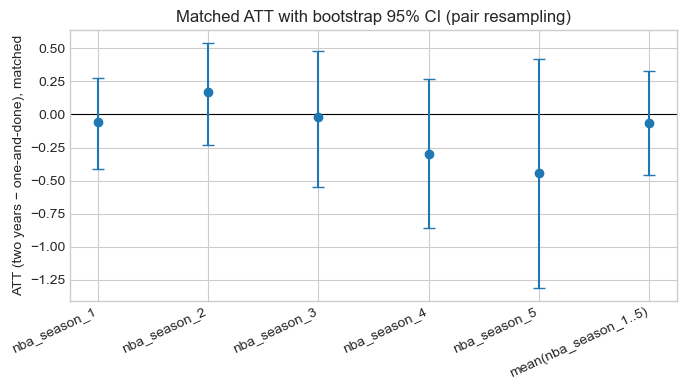

In [29]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(att_table))
ax.axhline(0, color="k", lw=0.8)
ax.errorbar(
    x,
    att_table["ATT"],
    yerr=[
        att_table["ATT"] - att_table["boot_ci_low"],
        att_table["boot_ci_high"] - att_table["ATT"],
    ],
    fmt="o",
    capsize=4,
    color="C0",
)
ax.set_xticks(x)
ax.set_xticklabels(att_table["outcome"], rotation=25, ha="right")
ax.set_ylabel("ATT (two years − one-and-done), matched")
ax.set_title("Matched ATT with bootstrap 95% CI (pair resampling)")
plt.tight_layout()
plt.show()

- Point estimates vary by season (e.g. positive in season 2 and 5, negative in 3–4), but the CIs are wide—especially later seasons—consistent with fewer non-missing NBA observations and only 76 matched pairs driving the estimates.

- If the 95% CI includes 0, then values consistent with your data include:
    - negative effects (two-year worse),
    - zero effect (no difference),
    - positive effects (two-year better).
    - In that sense, the data are not precise enough to rule out “no effect” at the 95% level.

- With only 76 matched pairs (and additional missingness in later NBA seasons), the distribution of is relatively wide, so the bootstrap percentiles span both sides of 0.
    - $ATT = \overline{d} = Avg(d_i = Y_{treated, i} - Y_{control, i})$
    - This is mainly about uncertainty/precision, not proof that the true effect is exactly zero.

### Conclusion

- **In this dataset, after propensity-based 1:1 matching on freshman performance, there is no statistically distinguishable difference in early NBA season metrics (or their average) between matched two-year players and matched one-and-dones; however, a large fraction of two-year players could not be matched, and unobserved confounding remains plausible, so the result is best read as “no clear evidence in this matched subsample,” not a definitive causal null.**

- **Identification:** Results are only as credible as the assumption that `college_1` (plus functional form in the propensity model) captures confounding of the stay/leave decision. Talent, injury, academics, and draft advisory information are not in the table.
- **ATT vs IPW:** The **matched ATT** answers “for two-year players who find a comparable one-and-done peer on freshman performance, what is the average difference in NBA metrics?” The **Hájek IPW** row is a weighting **ATE**-style contrast on the same analytic sample (different estimand).
- **Tuning:** Toggle `USE_OVERLAP_RESTRICTION` and `caliper_mult` in earlier cells to assess sensitivity.